# Example usage

To use `rowland_geometry` in a project:

In [1]:
import rowland_geometry

print(rowland_geometry.__version__)

0.1.0


# Using an Analyzer

### Example: Analyzer d-spacing and backscattering energy

Use an ``Analyzer`` to determine the interplanar spacing and backscattering
energy, E0, of a selected reflection. E0 is the minimum analyzable 
photon energy and corresponds to a Bragg angle = 90 deg. These are attributes
of the class.

In [3]:
from rowland_geometry import Analyzer

si_531 = Analyzer(
    material="Si",                          # Materials: Si, Ge, Quartz, Sapphire, LiNbO3, 
    reflection=[5, 3, 1],
    )

print(f"d-spacing = {si_531.d_hkl:.4f} Å")  # Analyzer.d_hkl
print(f"E0 = {si_531.e0:.2f} eV")           # Analyzer.e0

d-spacing = 0.9180 Å
E0 = 6752.98 eV


### Example: Analyzer Bragg angle to energy

Use an ``Analyzer`` to convert a Bragg angle in degrees to the analyzed
photon energy in eV.

In [4]:
from rowland_geometry import Analyzer   

ge_333 = Analyzer(
    material="Ge",                      # Materials: Si, Ge, Quartz, Sapphire, LiNbO3
    reflection=[3, 3, 3],
    )

bragg = 75                              # Bragg angle free parameter
energy = ge_333.to_energy(bragg)        # Analyzer.to_energy()

print(f"Energy at Bragg angle {bragg}° = {energy:.2f} eV")

Energy at Bragg angle 75° = 5894.21 eV


### Example: Analyzer energy to Bragg angle

Use an ``Analyzer`` to convert the analyzed photon energy in eV
to Bragg angle in degrees.

In [5]:
from rowland_geometry import Analyzer   

qtz_111 = Analyzer(
    material="Quartz",                  # Materials: Si, Ge, Quartz, Sapphire, LiNbO3
    reflection=[1, 1, 1],               # 4-index notation for hexagonal systems is also ok
    )

energy = 3000                           # Analyzed photon energy
bragg = qtz_111.to_bragg(energy)        # Analyzer.to_bragg()

print(f"Bragg angle at {energy:.0f} eV = {bragg:.2f}°")

Bragg angle at 3000 eV = 67.49°


### Example: Asymmetric analyzer definition

Define an ``Analyzer`` for asymmetric operation, where the diffracting
reflection does not coincide with the nominally surface coincident cut
of the optic. After instantiation, read out the asymmetry angle (alpha) 
using the ``Analyzer.asymmetry`` property.

In [6]:
from rowland_geometry import Analyzer   

si_asym = Analyzer(
    material="Si",              # Materials: Si, Ge, Quartz, Sapphire, LiNbO3, 
    reflection=[5, 5, 1],       # Asymmetric reflection used for photon analysis
    cut=[2, 1, 1],              # Cut of the optic 
    )                           

print(f"Asymmetry angle = {si_asym.asymmetry:.2f}°")  # Analyzer.asymmetry

Asymmetry angle = 23.84°


# Inspecting Rowland Geometry

### Example: The chord lengths of a Rowland circle

Use a ``RowlandCircle`` at a given Bragg angle to inspect the chord lengths
between the optic elemenets. This is a purely geometric construction in a 
fixed canonical reference frame; i.e. no use of analyzer crystals or analyzed
energies for this object or changing the reference frame of the Rowland Circle. 
For that, see ``Spectrometer``.

In [7]:
from rowland_geometry import RowlandCircle

circle = RowlandCircle(
    diameter=500,
    bragg=80
    )

circle.as_dict()

{'diameter': 500.0,
 'bragg': 80.0,
 'asymmetry': 0.0,
 'chord_rho': 492.403876506104,
 'chord_fm': 492.403876506104,
 'chord_fs': 524.00526045877,
 'pos_source': [-85.5050358314172, 484.923155196477, 0.0],
 'pos_analyzer': [0.0, 0.0, 0.0],
 'pos_meridional': [85.5050358314172, 484.923155196477, 0.0],
 'pos_sagittal': [90.99255856655063, 516.044443118978, 0.0],
 'pos_center': [0.0, 250.0, 0.0]}

### Example: Mutating state of an asymmetric Rowland circle

Use a ``RowlandCircle`` at a given Bragg angle and asymmetry angle alpha
to instatiate and inspect the chord lengths. Then, change the object's
bragg angle and asymmetry values and reinspect.

In [8]:
from rowland_geometry import RowlandCircle
from IPython.display import display

circle = RowlandCircle(
    diameter=500,
    bragg=80,
    asymmetry=15,
    )

print("Initial geometry:")
display(circle.as_dict())

circle.diameter = 1000
print("After changing diameter:")
display(circle.as_dict())

circle.bragg = 75
print("After changing Bragg angle:")
display(circle.as_dict())

circle.asymmetry = 10
print("After changing asymmetry:")
display(circle.as_dict())

Initial geometry:


{'diameter': 500.0,
 'bragg': 80.0,
 'asymmetry': 15.0,
 'chord_rho': 498.09734904587276,
 'chord_fm': 453.153893518325,
 'chord_fs': 555.9443052110298,
 'pos_source': [43.41204441673262, 496.201938253052, 0.0],
 'pos_analyzer': [0.0, 0.0, 0.0],
 'pos_meridional': [191.5111107797445, 410.69690242163483, 0.0],
 'pos_sagittal': [234.9522158929263, 503.85665297143635, 0.0],
 'pos_center': [0.0, 250.0, 0.0]}

After changing diameter:


{'diameter': 1000.0,
 'bragg': 80.0,
 'asymmetry': 15.0,
 'chord_rho': 996.1946980917455,
 'chord_fm': 906.30778703665,
 'chord_fs': 1111.8886104220596,
 'pos_source': [86.82408883346524, 992.403876506104, 0.0],
 'pos_analyzer': [0.0, 0.0, 0.0],
 'pos_meridional': [383.022221559489, 821.3938048432697, 0.0],
 'pos_sagittal': [469.9044317858526, 1007.7133059428727, 0.0],
 'pos_center': [0.0, 500.0, 0.0]}

After changing Bragg angle:


{'diameter': 1000.0,
 'bragg': 75.0,
 'asymmetry': 15.0,
 'chord_rho': 1000.0,
 'chord_fm': 866.0254037844386,
 'chord_fs': 1154.7005383792516,
 'pos_source': [-6.123233995736766e-14, 1000.0, 0.0],
 'pos_analyzer': [0.0, 0.0, 0.0],
 'pos_meridional': [433.0127018922194, 749.9999999999999, 0.0],
 'pos_sagittal': [577.3502691896259, 1000.0, 0.0],
 'pos_center': [0.0, 500.0, 0.0]}

After changing asymmetry:


{'diameter': 1000.0,
 'bragg': 75.0,
 'asymmetry': 10.0,
 'chord_rho': 996.1946980917455,
 'chord_fm': 906.30778703665,
 'chord_fs': 1111.8886104220596,
 'pos_source': [-86.82408883346514, 992.403876506104, 0.0],
 'pos_analyzer': [0.0, 0.0, 0.0],
 'pos_meridional': [383.022221559489, 821.3938048432697, 0.0],
 'pos_sagittal': [469.9044317858526, 1007.7133059428727, 0.0],
 'pos_center': [0.0, 500.0, 0.0]}

# Defining and Using a Spectrometer

### Example: Instantiating a spectrometer from a Bragg angle

Instantiate a ``RowlandSpectrometer`` at a given Bragg angle by first
defining the ``Analyzer`` (and reflection) that define the Rowland circle.

In [ ]:
from rowland_geometry import Analyzer, RowlandSpectrometer
from IPython.display import display

si_531 = Analyzer(
    material="Si",                          
    reflection=[5, 3, 1],
    cut=[2,1,1],
    bending_radius=500
    )

xas_spec = RowlandSpectrometer(analyzer=si_531,
                              bragg=82
                              )

display(xas_spec.as_dict())

{'energy': 6819.342083184592,
 'bragg': 82.0,
 'asymmetry': 14.963217433307127,
 'analyzer': {'material': 'Silicon',
  'reflection': [5, 3, 1],
  'cut': [2, 1, 1],
  'bending_radius': 500.0,
  'optic_diameter': 100.0,
  'd_hkl': 0.9179965786659089,
  'e0': 6752.976714803323,
  'crystal_asymmetry': 14.963217433307127,
  'miscut': 0.0,
  'asymmetry': 14.963217433307127},
 'rowland': {'diameter': 500.0,
  'chord_rho': 496.31209220379645,
  'chord_fm': 460.37775205323794,
  'chord_fs': 551.2550967891932},
 'focus': {'optic_diameter': 100.0,
  'extent_meridional': 16.53089109093783,
  'extent_sagittal': 18.310523995582816},
 'reference_frame': {'origin': 'analyzer',
  'axis_element': 'center',
  'axis': 'y',
  'rotation': 0.0,
  'flip_x': False,
  'flip_y': False},
 'coords_reference_frame': {'source': [60.16897041399876,
   492.6513857354195,
   0.0],
  'analyzer': [0.0, 0.0, 0.0],
  'meridional': [179.61182460136507, 423.8953491711853, 0.0],
  'sagittal': [215.06672143370514, 507.57116453

### Example: Instantiating a spectrometer from an energy

Similarly, a ``RowlandSpectrometer`` can also be instantiateed from
an analyzed energy.

In [ ]:
from rowland_geometry import Analyzer, RowlandSpectrometer
from IPython.display import display

si_531 = Analyzer(
    material="Si",                          
    reflection=[5, 3, 1],
    cut=[2,1,1],
    bending_radius=500
    )

xas_spec = RowlandSpectrometer(analyzer=si_531,
                              energy=7800
                              )

display(xas_spec.as_dict())

{'energy': 7800.0,
 'bragg': 59.970315963859804,
 'asymmetry': 14.963217433307127,
 'analyzer': {'material': 'Silicon',
  'reflection': [5, 3, 1],
  'cut': [2, 1, 1],
  'bending_radius': 500.0,
  'optic_diameter': 100.0,
  'd_hkl': 0.9179965786659089,
  'e0': 6752.976714803323,
  'crystal_asymmetry': 14.963217433307127,
  'miscut': 0.0,
  'asymmetry': 14.963217433307127},
 'rowland': {'diameter': 500.0,
  'chord_rho': 482.8124652584131,
  'chord_fm': 353.5971905745752,
  'chord_fs': 762.2559417319683},
 'focus': {'optic_diameter': 100.0,
  'extent_meridional': 53.68877402081838,
  'extent_sagittal': 84.64130082860822},
 'reference_frame': {'origin': 'analyzer',
  'axis_element': 'center',
  'axis': 'y',
  'rotation': 0.0,
  'flip_x': False,
  'flip_y': False},
 'coords_reference_frame': {'source': [-125.50198428891044,
   466.21575321781273,
   0.0],
  'analyzer': [0.0, 0.0, 0.0],
  'meridional': [249.99999232529575, 250.06194636446494, 0.0],
  'sagittal': [538.9295635331479, 539.06311

### Example: Reading only the coordinates of the spectrometer elements


In [ ]:
from rowland_geometry import Analyzer, RowlandSpectrometer
from IPython.display import display

si_531 = Analyzer(
    material="Si",                          
    reflection=[5, 3, 1],
    cut=[2,1,1],
    bending_radius=500
    )

xas_spec = RowlandSpectrometer(analyzer=si_531,
                              energy=7800
                              )

display(xas_spec.coords_reference_frame())

{'source': array([-125.50198429,  466.21575322,    0.        ]),
 'analyzer': array([0., 0., 0.]),
 'meridional': array([249.99999233, 250.06194636,   0.        ]),
 'sagittal': array([538.92956353, 539.06311899,   0.        ]),
 'center': array([  0., 250.,   0.])}

### Example: Mutating the state of a spectrometer

The ``RowlandSpectrometer`` can change configuration by specifying a new
Bragg angle, energy, or swapping an optic. In the case of optic swapping,
the Bragg angle is kept constant between the two configurations.

In [ ]:
from rowland_geometry import Analyzer, RowlandSpectrometer
from IPython.display import display

si_531 = Analyzer(
    material="Si",                          
    reflection=[5, 3, 1],
    cut=[2,1,1],
    bending_radius=500
    )

xas_spec = RowlandSpectrometer(analyzer=si_531,
                              energy=7800
                              )

xas_spec.energy = 7000               # Changing the energy of the spectrometer

print("After changing Energy:")
display(xas_spec.as_dict())

xas_spec.bragg = 80                  # Changing the Bragg angle of the spectrometer

print("After changing Bragg:")
display(xas_spec.as_dict())

ge_333 = Analyzer(                  # Defining a new (symmetric) analyzer
    material="Ge",                          
    reflection=[3, 3, 3],
    bending_radius=500
    )
xas_spec.analyzer = ge_333           # Changing the analyzer of the spectrometer

print("After changing analyzer:")
display(xas_spec.as_dict())

After changing Energy:


{'energy': 7000.0,
 'bragg': 74.73337444277597,
 'asymmetry': 14.963217433307127,
 'analyzer': {'material': 'Silicon',
  'reflection': [5, 3, 1],
  'cut': [2, 1, 1],
  'bending_radius': 500.0,
  'optic_diameter': 100.0,
  'd_hkl': 0.9179965786659089,
  'e0': 6752.976714803323,
  'crystal_asymmetry': 14.963217433307127,
  'miscut': 0.0,
  'asymmetry': 14.963217433307127},
 'rowland': {'diameter': 500.0,
  'chord_rho': 499.9929895137937,
  'chord_fm': 432.006341271536,
  'chord_fs': 578.7114376478798},
 'focus': {'optic_diameter': 100.0,
  'extent_meridional': 25.413568758664944,
  'extent_sagittal': 29.341430670658752},
 'reference_frame': {'origin': 'analyzer',
  'axis_element': 'center',
  'axis': 'y',
  'rotation': 0.0,
  'flip_x': False,
  'flip_y': False},
 'coords_reference_frame': {'source': [-2.647685871553744,
   499.9859791258813,
   0.0],
  'analyzer': [0.0, 0.0, 0.0],
  'meridional': [217.50225130476278, 373.2589577976376, 0.0],
  'sagittal': [291.36387251573683, 500.0140216

After changing Bragg:


{'energy': 6857.152265656067,
 'bragg': 80.0,
 'asymmetry': 14.963217433307127,
 'analyzer': {'material': 'Silicon',
  'reflection': [5, 3, 1],
  'cut': [2, 1, 1],
  'bending_radius': 500.0,
  'optic_diameter': 100.0,
  'd_hkl': 0.9179965786659089,
  'e0': 6752.976714803323,
  'crystal_asymmetry': 14.963217433307127,
  'miscut': 0.0,
  'asymmetry': 14.963217433307127},
 'rowland': {'diameter': 500.0,
  'chord_rho': 498.12522238904904,
  'chord_fm': 453.28945570882985,
  'chord_fs': 555.7148933741261},
 'focus': {'optic_diameter': 100.0,
  'extent_meridional': 18.48119007421757,
  'extent_sagittal': 20.562186587150816},
 'reference_frame': {'origin': 'analyzer',
  'axis_element': 'center',
  'axis': 'y',
  'rotation': 0.0,
  'flip_x': False,
  'flip_y': False},
 'coords_reference_frame': {'source': [43.0958968081237,
   496.25747436027916,
   0.0],
  'analyzer': [0.0, 0.0, 0.0],
  'meridional': [191.30462558258023, 410.9426613136144, 0.0],
  'sagittal': [234.5318830356587, 503.799403093

After changing analyzer:


{'energy': 5781.194906836385,
 'bragg': 80.0,
 'asymmetry': 0.0,
 'analyzer': {'material': 'Germanium',
  'reflection': [3, 3, 3],
  'cut': [3, 3, 3],
  'bending_radius': 500.0,
  'optic_diameter': 100.0,
  'd_hkl': 1.088847966675483,
  'e0': 5693.365565927162,
  'crystal_asymmetry': 0.0,
  'miscut': 0.0,
  'asymmetry': 0.0},
 'rowland': {'diameter': 500.0,
  'chord_rho': 492.403876506104,
  'chord_fm': 492.403876506104,
  'chord_fs': 524.00526045877},
 'focus': {'optic_diameter': 100.0,
  'extent_meridional': 6.049107641191669,
  'extent_sagittal': 6.417777247591232},
 'reference_frame': {'origin': 'analyzer',
  'axis_element': 'center',
  'axis': 'y',
  'rotation': 0.0,
  'flip_x': False,
  'flip_y': False},
 'coords_reference_frame': {'source': [-85.5050358314172,
   484.923155196477,
   0.0],
  'analyzer': [0.0, 0.0, 0.0],
  'meridional': [85.5050358314172, 484.923155196477, 0.0],
  'sagittal': [90.99255856655063, 516.044443118978, 0.0],
  'center': [0.0, 250.0, 0.0]}}

### Example: Quickly readinng state with ``snapshot()``
Displaying the ``RowlandSpectrometer`` using ``as_dict()`` is not often the most convenient. A powerful, flat non-nested output of the relevant chords and coordinates while the spectrometer state is changed can be generated using the ``snapshot()`` function. Here, an example of the output is shown. Later in this notebook, ``snapshot()`` is used to generate and save the output over many state changes of the spectrometer to be used in generating a scan definition.

In [8]:
from rowland_geometry import Analyzer, RowlandSpectrometer
from IPython.display import display

si_531 = Analyzer(
    material="Si",                          
    reflection=[5, 3, 1],
    cut=[2,1,1],
    bending_radius=500
    )

xas_spec = RowlandSpectrometer(analyzer=si_531,
                              energy=7400
                              )

display(xas_spec.snapshot())

{'energy': 7400.0,
 'bragg': 65.86217646098257,
 'asymmetry': 14.963217433307127,
 'theta_m': 80.82539389428969,
 'rowland.diameter': 500.0,
 'rowland.chord_rho': 493.6035142949165,
 'rowland.chord_fm': 388.0174742858009,
 'rowland.chord_fs': 661.557904691786,
 'focus.extent_meridional': 41.42682923873056,
 'focus.extent_sagittal': 55.41703462073633,
 'source.x': -78.70195398624143,
 'source.y': 487.2888586485837,
 'source.z': 0.0,
 'analyzer.x': 0.0,
 'analyzer.y': 0.0,
 'analyzer.z': 0.0,
 'meridional.x': 244.71870471133374,
 'meridional.y': 301.11512070226433,
 'meridional.z': 0.0,
 'sagittal.x': 417.2378932822775,
 'sagittal.y': 513.3920545446268,
 'sagittal.z': 0.0,
 'center.x': 0.0,
 'center.y': 250.0,
 'center.z': 0.0}

### Example: Reading the sagittal and meridional foci extents

With the diameter of the optic in ``Analyzer``, the ``RowlandSpectrometer`` can be used to estimate the sagittal and meridional focal spot size extents at a given Bragg angle. 

In [40]:
from rowland_geometry import Analyzer, RowlandSpectrometer
from IPython.display import display

si_531 = Analyzer(
    material="Si",                          
    reflection=[5, 3, 1],
    cut=[2,1,1],
    bending_radius=500,
    optic_diameter=100              # Defaults to 100 mm if not specified
    )

xas_spec = RowlandSpectrometer(analyzer=si_531,
                              bragg=75
                              )


print(f"Meridional extent = {xas_spec.extent_meridional:.1f} mm")
print(f"Sagittal extent = {xas_spec.extent_sagittal:.1f} mm")


Meridional extent = 25.0 mm
Sagittal extent = 28.8 mm


### Helper Function for Plotting the Following Examples

This plotting code block will recur for several of the next examples. Thus, here it is defined as a function for use later.

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_geometry(spec):

    coords = spec.coords_reference_frame()

    source = coords["source"]
    optic = coords["analyzer"]
    meridional = coords["meridional"]
    sagittal = coords["sagittal"]
    center = coords["center"]

    fig, ax = plt.subplots(figsize=(7, 7))

    rowland_radius = spec.diameter / 2

    ax.add_patch(
        Circle(
            (center[0], center[1]),
            rowland_radius,
            fill=False,
            color="k",
            lw=1.5,
            zorder=1,
        )
    )

    ax.plot(
        [source[0], optic[0]],
        [source[1], optic[1]],
        color="k",
        lw=1.5,
        zorder=2,
    )

    ax.plot(
        [optic[0], sagittal[0]],
        [optic[1], sagittal[1]],
        color="k",
        lw=1.5,
        zorder=2,
    )

    ax.plot(
        [optic[0], meridional[0]],
        [optic[1], meridional[1]],
        ls="--",
        color="k",
        lw=1.2,
        zorder=2,
    )

    ax.scatter(source[0], source[1], s=80, label="Source", zorder=10)
    ax.scatter(optic[0], optic[1], s=80, label="Analyzer", zorder=10)
    ax.scatter(
        meridional[0],
        meridional[1],
        s=80,
        label="Meridional focus",
        zorder=10,
    )
    ax.scatter(
        sagittal[0],
        sagittal[1],
        s=80,
        label="Sagittal focus",
        zorder=10,
    )

    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")

    plt.show()

### Example: Plotting the (canonical) spectrometer geometry

The ``RowlandSpectrometer`` has a default canonical reference frame and scanning geometry, wherein the optic is fixed at the origin and the circle center is constrained to the y-axis while the spectrometer scans. The fixed element during scanning and the reference frame are changeable, see later examples, but first this example plots the canonical geometry before any transforms. Note the orientation of the Rowland circle and the location of the origin on the plot.

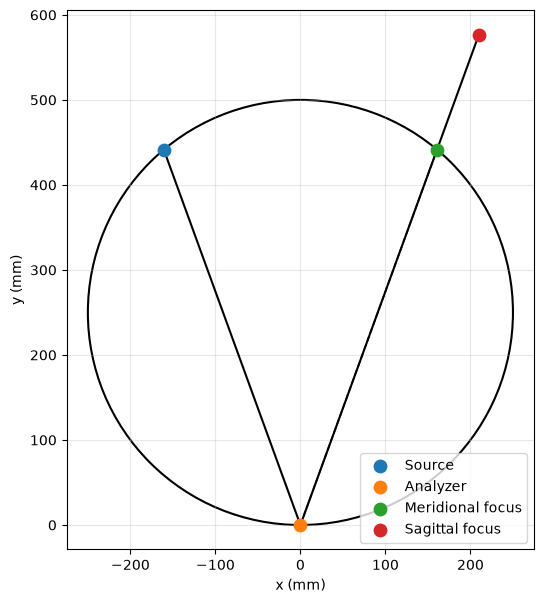

In [ ]:
from rowland_geometry import Analyzer, RowlandSpectrometer


# Instantiating an analyzer and the spectrometer at a given Bragg angle
si_531 = Analyzer(
    material="Si",                          
    reflection=[5, 3, 1],       # No cut specified; so this defaults to symmetric
    bending_radius=500
    )

xas_spec = RowlandSpectrometer(analyzer=si_531,
                              bragg=70             # Reminder - this could be defined with energy also
                              )

# Plotting
plot_geometry(xas_spec)


### Example: Applying a Reference Frame -- Table Scanning Geometry

The ``RowlandSpectrometer`` can be instantiated with an optional ``ReferenceFrame``, which transforms the coordinates and the fixed element of the scanning spectrometer. This example transforms and plots the coordinates of the spectrometer in a so-called Table Scanning geometry, where the source is fixed and the optic translates vertically. Note the orientation of the Rowland circle and the location of the origin on the plot.

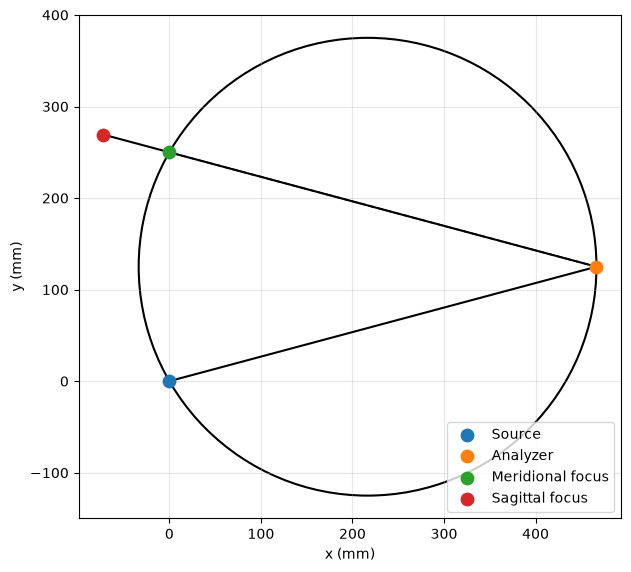

In [ ]:
from rowland_geometry import Analyzer, RowlandSpectrometer, ReferenceFrame


# Defining the reference frame
tbl_frame = ReferenceFrame(
    origin="source",              # source, analyzer, meridional, sagittal, or center
    axis_element="meridional",    # source, analyzer, meridional, sagittal, or center
    axis="y",                     # the axis to place the 'axis_element' along, x or y
    )

# Instantiating the analyzer
si_531 = Analyzer(
    material="Si",                          
    reflection=[5, 3, 1],       
    bending_radius=500
    )

# Instantiating the spectrometer with a reference frame
xas_spec = RowlandSpectrometer(analyzer=si_531,
                              bragg=75,             
                              frame=tbl_frame   # Need to include the reference frame when instantiating the spectrometer
                              )

# Plotting
plot_geometry(xas_spec)


### Example: Applying a Reference Frame -- Tilt Scanning Geometry

Here, the ``RowlandSpectrometer`` is instantiated with a ``ReferenceFrame`` to transform and plot the coordinates of the spectrometer in a so-called Tilt Scanning geometry, where the source is fixed and the optic remains in the horizontal plane. Note the orientation of the Rowland circle and the location of the origin on the plot.

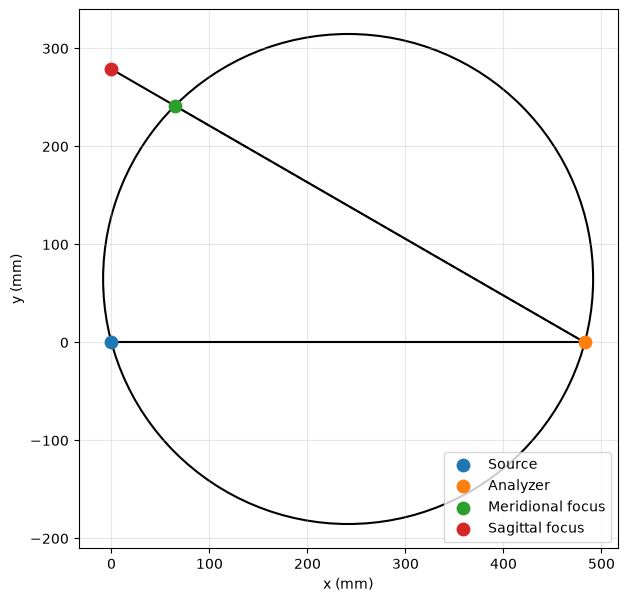

In [ ]:
from rowland_geometry import Analyzer, RowlandSpectrometer, ReferenceFrame


# Defining the reference frame
tilt_frame = ReferenceFrame(
    origin="source",              # source, analyzer, meridional, sagittal, or center
    axis_element="analyzer",      # source, analyzer, meridional, sagittal, or center
    axis="x",                     # the axis to place the 'axis_element' along, x or y
    )

# Instantiating the analyzer
si_531 = Analyzer(
    material="Si",                          
    reflection=[5, 3, 1],       
    bending_radius=500
    )

# Instantiating the spectrometer with a reference frame
xas_spec = RowlandSpectrometer(analyzer=si_531,
                              bragg=75,             
                              frame=tilt_frame
                              )

# Plotting
plot_geometry(xas_spec)


### Example: Applying a Reference Frame -- Fixed Detector, Asymmetric Analyzer, Mirroring the Axes

Here, the ``RowlandSpectrometer`` is instantiated with a ``ReferenceFrame`` to transform and plot the coordinates of the spectrometer in a fixed detector geometry, where the meridional focus remains fixed on the origin. To further demonstrate customability, the axes are mirrored when instantiating the ``ReferenceFrame``. When defining the ``Analyzer``, a ``cut`` is specified that differs from ``reflection``, so the Rowland geometry is also asymmetric. Note the orientation of the Rowland circle and the location of the origin on the plot.

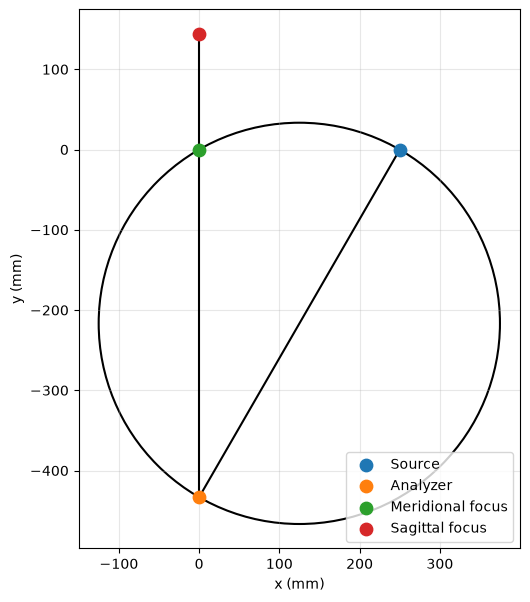

In [ ]:
from rowland_geometry import Analyzer, RowlandSpectrometer, ReferenceFrame


# Defining the reference frame
det_frame = ReferenceFrame(
    origin="meridional",                # source, analyzer, meridional, sagittal, or center
    axis_element="analyzer",            # source, analyzer, meridional, sagittal, or center
    axis="y",                           # the axis to place the 'axis_element' along, x or y
    flip_x=False,                       # mirrors the reference frame about the x axis
    flip_y=True,                        # mirrors the reference frame about the y axis
    rotation=0                          # rotates the reference frame in degrees about origin
    )

# Instantiating the analyzer
si_531 = Analyzer(
    material="Si",                          
    reflection=[5, 3, 1],       
    cut=[2,1,1],                        # cut specified different from reflection = asymmetric
    bending_radius=500
    )

# Instantiating the spectrometer with a reference frame
xas_spec = RowlandSpectrometer(analyzer=si_531,
                              bragg=75,             # Reminder - this could be defined with energy also
                              frame=det_frame
                              )

# Plotting
plot_geometry(xas_spec)


### Example: Using a defined Spectrometer to make a scan definition

We can instantiate a ``RowlandSpectrometer`` in a ``ReferenceFrame`` with an ``Analyzer`` matching experimental conditions. Thus, a scan def can be created from the tools here to, for example, run a scan in an asymmetric Rowland geometry where the detector tracks the sagittal focus off-circle. To demonstrate, the tilt-scan reference frame is used. By changing the analyzed photon energy and recording snapshot() at each point, a scan definition can be generated containing the corresponding Rowland geometry and element coordinates. Snapshot() is a handy function -- snapshot() contains the coordinates and chords of every element of the spectrometer in the specified reference frame.

In [ ]:
from rowland_geometry import Analyzer, RowlandSpectrometer, ReferenceFrame


# Defining the tilt scan reference frame from earlier example
tilt_frame = ReferenceFrame(
    origin="source",              
    axis_element="analyzer",      
    axis="x",                     
    )

# Instantiating the analyzer
si_531 = Analyzer(
    material="Si",                          
    reflection=[5, 3, 1],
    cut = [2,1,1],       
    bending_radius=500
    )

# Instantiating the spectrometer with a reference frame
xas_spec = RowlandSpectrometer(analyzer=si_531,
                              bragg=75,             
                              frame=tilt_frame
                              )

# Plotting, optional: 
# plot_geometry(xas_spec)


# Defining an energy scan
energies = [7500, 7600, 7700, 7800, 7900]
scan = []

for energy in energies:
    xas_spec.energy = energy
    scan.append(xas_spec.snapshot())  # every chord and coordinate in the specified reference frame


# Print only a subset of the quantities recorded by snapshot()
for point in scan:
    print(
        f"E = {point['energy']:.1f} eV, "
        f"Bragg = {point['bragg']:.2f}°, "
        f"Sagittal x = {point['sagittal.x']:.2f} mm, "
        f"Sagittal y = {point['sagittal.y']:.2f} mm"
    )


# Exporting result
# import csvcd
# with open("scan_definition.csv", "w", newline="") as f:
#     writer = csv.DictWriter(f, fieldnames=scan[0].keys())
#     writer.writeheader()
#     writer.writerows(scan)

E = 7500.0 eV, Bragg = 64.21°, Sagittal x = 65.36 mm, Sagittal y = 536.75 mm
E = 7600.0 eV, Bragg = 62.69°, Sagittal x = 77.49 mm, Sagittal y = 578.62 mm
E = 7700.0 eV, Bragg = 61.28°, Sagittal x = 89.80 mm, Sagittal y = 619.77 mm
E = 7800.0 eV, Bragg = 59.97°, Sagittal x = 102.37 mm, Sagittal y = 660.53 mm
E = 7900.0 eV, Bragg = 58.74°, Sagittal x = 115.28 mm, Sagittal y = 701.14 mm
